# 06 — Entraînement des modèles de prédiction du churn

> **Objectif de ce notebook :** trouver, de façon rigoureuse, le meilleur modèle
> capable de prédire si un client de TelcoConnect va résilier son abonnement (*churn*).

### 🧭 Pour quelqu'un qui découvre le Machine Learning

Prédire le churn, c'est répondre à une question simple : **« ce client risque-t-il de partir ? »**
On parle d'un problème de **classification binaire** : la réponse est *Oui* (churn = 1) ou *Non* (churn = 0).

Pour y répondre, on va **entraîner** des modèles : on leur montre des milliers de clients dont on
connaît déjà le résultat (parti / resté), ils apprennent les régularités, puis on les teste sur des
clients qu'ils n'ont **jamais vus** pour mesurer s'ils généralisent bien.

**Le plan, étape par étape :**
1. Charger les données déjà nettoyées et préparées (notebooks 01 → 05).
2. Comprendre les **métriques** qui comptent ici.
3. Comparer **5 modèles** dans leur configuration de base (*baseline*).
4. **Optimiser** les meilleurs en testant plusieurs **configurations** (hyperparamètres).
5. **Choisir** le meilleur et l'évaluer en détail sur le jeu de test.
6. **Interpréter** ce qui pousse les clients à partir.
7. **Régler le seuil** de décision selon le besoin métier, puis **sauvegarder** le modèle.

## 1. Imports & chargement des données

Les fichiers `X_train` / `X_test` sont **déjà mis à l'échelle et encodés** (notebook 05).
On les charge tels quels — il ne faut surtout pas refaire la préparation (cela fausserait les données).

- `X_train` / `y_train` : ce que le modèle utilise pour **apprendre** (75 % des clients).
- `X_test` / `y_test` : ce qu'on garde de côté pour **juger** le modèle (25 %), jamais vu à l'entraînement.

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # pour des résultats reproductibles

In [2]:
DATA = Path('../data')
MODELS = Path('../models')
REPORTS = Path('../reports')

X_train = pd.read_csv(DATA / 'X_train.csv')
X_test = pd.read_csv(DATA / 'X_test.csv')
y_train = pd.read_csv(DATA / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(DATA / 'y_test.csv').squeeze('columns')

print(f'Entraînement : {X_train.shape[0]:,} clients, {X_train.shape[1]} caractéristiques')
print(f'Test         : {X_test.shape[0]:,} clients')
X_train.head()

Entraînement : 49,824 clients, 29 caractéristiques
Test         : 16,609 clients


,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharge,ChargeDiff,TotalServices,Contract,TenureGroups,MultipleLines_No phone service,MultipleLines_Yes,...,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,IsMonthly,IsSingle
0,1.113076,-0.841226,-0.047170,-0.833735,-0.045721,0.031135,0.0,2.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.234152,-0.743949,-0.957225,-0.736714,-0.045721,1.033250,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
2,-0.125739,-0.609201,-0.409916,-0.602319,-0.045721,-0.970980,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.069863,2.578963,1.611623,2.577470,-0.045721,2.035365,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.938697,-0.264381,1.656319,-0.258405,-0.045721,-0.970980,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## 2. Équilibre des classes : combien de clients partent ?

Avant d'entraîner quoi que ce soit, on regarde la **répartition de la cible**. Si une classe était
très rare (ex. 2 % de churn), un modèle paresseux qui répond toujours *« ne part pas »* aurait 98 %
de bonnes réponses… tout en étant inutile. C'est le piège des données **déséquilibrées**.

Ici le churn est à ~47 % : les données sont **quasi équilibrées**, on n'a donc pas besoin de techniques
spéciales (sur-échantillonnage type SMOTE). On surveillera quand même le **Recall** (voir §3).

Churn
Reste (0)    53.1 %
Churn (1)    46.9 %
Name: proportion, dtype: object


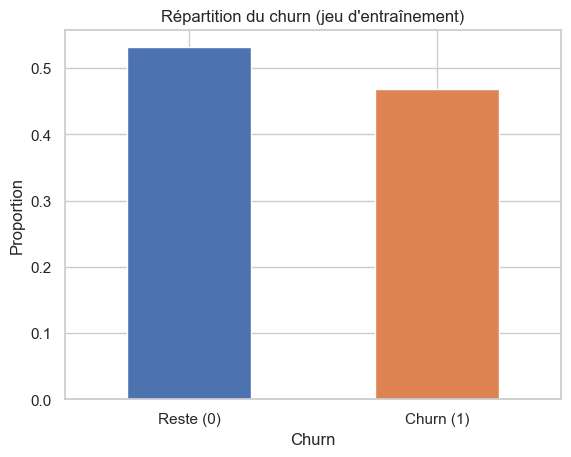

In [3]:
balance = y_train.value_counts(normalize=True).rename({0: 'Reste (0)', 1: 'Churn (1)'})
print((balance * 100).round(1).astype(str) + ' %')
ax = balance.plot(kind='bar', color=['#4c72b0', '#dd8452'], rot=0,
                  title='Répartition du churn (jeu d\'entraînement)')
ax.set_ylabel('Proportion'); plt.show()

## 3. Quelles métriques regarder ? (et pourquoi)

Une **métrique** mesure la qualité des prédictions. Toutes ne se valent pas selon le problème :

| Métrique | Question à laquelle elle répond | Pourquoi elle compte ici |
|----------|-------------------------------|--------------------------|
| **Accuracy** | Quelle part de prédictions sont correctes ? | Utile mais trompeuse si déséquilibre |
| **Precision** | Parmi les clients prédits *churn*, combien le sont vraiment ? | Évite de gaspiller les actions de rétention |
| **Recall** | Parmi les vrais churners, combien on en détecte ? | ⭐ **Clé** : un churner manqué = client perdu |
| **F1-score** | Compromis entre Precision et Recall | Bon résumé global |
| **ROC-AUC** | Le modèle sait-il **classer** un churner au-dessus d'un non-churner ? | ⭐ Indépendant du seuil, idéal pour comparer |

👉 Pour la rétention client, **rater un churner (faux négatif) coûte plus cher** qu'une fausse alerte.
On privilégiera donc le **Recall** et le **ROC-AUC**.

In [4]:
def evaluate(model, X, y):
    """Calcule les 5 métriques sur un jeu (X, y)."""
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]  # probabilité d'être 'churn'
    return {
        'accuracy': accuracy_score(y, pred),
        'precision': precision_score(y, pred),
        'recall': recall_score(y, pred),
        'f1': f1_score(y, pred),
        'roc_auc': roc_auc_score(y, proba),
    }

## 4. Comparaison robuste de 5 modèles (validation croisée)

### Qu'est-ce que la validation croisée ?
Évaluer un modèle sur un seul découpage peut être chanceux ou malchanceux. La **validation croisée
en k plis** (ici *k = 5*) découpe l'entraînement en 5 parts : le modèle apprend sur 4 parts et est
testé sur la 5ᵉ, en tournant 5 fois. On obtient **5 scores** → leur moyenne est bien plus fiable,
et leur écart-type indique la **stabilité**. On utilise une version *stratifiée* qui conserve le
ratio de churn dans chaque pli.

### Les 5 modèles comparés
On part volontairement de familles variées, de la plus simple à la plus sophistiquée :
- **Logistic Regression** — modèle linéaire simple, notre *baseline* de référence.
- **Decision Tree** — un arbre de décision, très lisible mais sujet au sur-apprentissage.
- **Random Forest** — une *forêt* de centaines d'arbres qui votent : robuste.
- **HistGradientBoosting** — boosting d'arbres optimisé, rapide et performant.
- **XGBoost** — boosting de référence dans l'industrie.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                            subsample=0.9, colsample_bytree=0.9,
                            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}
print(f'{len(models)} modèles à comparer en validation croisée 5 plis...')

5 modèles à comparer en validation croisée 5 plis...


In [6]:
# Pour chaque modèle : score de validation croisée (ROC-AUC) puis évaluation sur le test
results, trained = {}, {}
for name, model in models.items():
    auc_cv = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    scores = evaluate(model, X_test, y_test)
    scores['cv_roc_auc_mean'] = auc_cv.mean()
    scores['cv_roc_auc_std'] = auc_cv.std()
    results[name] = scores
    trained[name] = model
    print(f'{name:22s} | CV ROC-AUC = {auc_cv.mean():.4f} (± {auc_cv.std():.4f}) '
          f"| test Recall = {scores['recall']:.3f} | test AUC = {scores['roc_auc']:.4f}")

Logistic Regression    | CV ROC-AUC = 0.7883 (± 0.0021) | test Recall = 0.898 | test AUC = 0.7910


Decision Tree          | CV ROC-AUC = 0.7878 (± 0.0032) | test Recall = 0.896 | test AUC = 0.7866


Random Forest          | CV ROC-AUC = 0.7875 (± 0.0023) | test Recall = 0.864 | test AUC = 0.7893


HistGradientBoosting   | CV ROC-AUC = 0.7896 (± 0.0028) | test Recall = 0.898 | test AUC = 0.7935


XGBoost                | CV ROC-AUC = 0.7897 (± 0.0023) | test Recall = 0.896 | test AUC = 0.7929


In [7]:
baseline = pd.DataFrame(results).T
baseline = baseline[['accuracy','precision','recall','f1','roc_auc','cv_roc_auc_mean','cv_roc_auc_std']].round(4)
baseline.sort_values('cv_roc_auc_mean', ascending=False)

,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean,cv_roc_auc_std
XGBoost,0.7694,0.6976,0.8964,0.7846,0.7929,0.7897,0.0023
HistGradientBoosting,0.7698,0.6975,0.8980,0.7852,0.7935,0.7896,0.0028
Logistic Regression,0.7698,0.6975,0.8980,0.7852,0.7910,0.7883,0.0021
Decision Tree,0.7690,0.6972,0.8963,0.7843,0.7866,0.7878,0.0032
Random Forest,0.7593,0.6959,0.8635,0.7707,0.7893,0.7875,0.0023


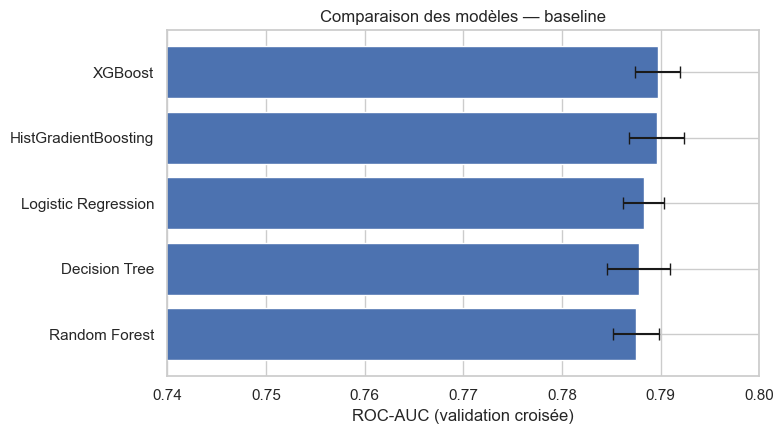

In [8]:
# Visualisation : ROC-AUC de validation croisée (avec barres d'erreur = stabilité)
order = baseline.sort_values('cv_roc_auc_mean')
plt.figure(figsize=(8, 4.5))
plt.barh(order.index, order['cv_roc_auc_mean'], xerr=order['cv_roc_auc_std'],
         color='#4c72b0', capsize=4)
plt.xlim(0.74, 0.80); plt.xlabel('ROC-AUC (validation croisée)')
plt.title('Comparaison des modèles — baseline'); plt.tight_layout(); plt.show()

**Comment lire ce graphique :** plus la barre est longue, meilleur est le modèle ; plus la barre
d'erreur est courte, plus il est **stable**. On constate que les modèles d'arbres boostés
(*XGBoost*, *HistGradientBoosting*) arrivent en tête, mais **de peu** : tous se tiennent autour de
**0.79 de ROC-AUC**. Ce *plafond* est un indice qu'on creusera au §7.

## 5. Optimisation des hyperparamètres (plusieurs configurations)

### Qu'est-ce qu'un hyperparamètre ?
Ce sont les **réglages** d'un modèle qu'on fixe *avant* l'entraînement (profondeur des arbres,
nombre d'arbres, vitesse d'apprentissage…). Le bon réglage peut améliorer les performances.

### Comment les chercher ?
Tester toutes les combinaisons (*GridSearch*) serait très long. On utilise **RandomizedSearchCV** :
il tire au sort des combinaisons, les évalue chacune en validation croisée, et garde la meilleure.
On l'applique aux **deux meilleures familles** d'arbres : Random Forest et XGBoost.

In [9]:
# --- Recherche pour Random Forest ---
rf_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    rf_grid, n_iter=6, scoring='roc_auc', cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1,
)
rf_search.fit(X_train, y_train)
print('RF — meilleure config :', rf_search.best_params_)
print('RF — meilleur CV ROC-AUC :', round(rf_search.best_score_, 4))

Fitting 5 folds for each of 6 candidates, totalling 30 fits


RF — meilleure config : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
RF — meilleur CV ROC-AUC : 0.7896


In [10]:
# --- Recherche pour XGBoost ---
xgb_grid = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid, n_iter=12, scoring='roc_auc', cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1,
)
xgb_search.fit(X_train, y_train)
print('XGB — meilleure config :', xgb_search.best_params_)
print('XGB — meilleur CV ROC-AUC :', round(xgb_search.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


XGB — meilleure config : {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
XGB — meilleur CV ROC-AUC : 0.7897


In [11]:
# On ajoute les versions optimisées au comparatif
for label, est, best in [('Random Forest (tuned)', rf_search.best_estimator_, rf_search.best_score_),
                         ('XGBoost (tuned)', xgb_search.best_estimator_, xgb_search.best_score_)]:
    s = evaluate(est, X_test, y_test)
    s['cv_roc_auc_mean'] = best
    results[label] = s
    trained[label] = est

final_table = pd.DataFrame(results).T[['accuracy','precision','recall','f1','roc_auc','cv_roc_auc_mean']].round(4)
final_table.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean
HistGradientBoosting,0.7698,0.6975,0.8980,0.7852,0.7935,0.7896
XGBoost,0.7694,0.6976,0.8964,0.7846,0.7929,0.7897
Logistic Regression,0.7698,0.6975,0.8980,0.7852,0.7910,0.7883
Random Forest (tuned),0.7698,0.6975,0.8980,0.7852,0.7908,0.7896
XGBoost (tuned),0.7655,0.6972,0.8832,0.7793,0.7901,0.7897
Random Forest,0.7593,0.6959,0.8635,0.7707,0.7893,0.7875
Decision Tree,0.7690,0.6972,0.8963,0.7843,0.7866,0.7878


### 💡 Enseignement important

Le réglage fin **n'améliore quasiment pas** les scores : les versions *tuned* font à peine mieux
(voire un peu moins bien à cause d'un léger sur-apprentissage). C'est un message clé en ML :
**plus de complexité ≠ toujours plus de performance**. Quand le signal utile est concentré dans
peu de variables (ce qu'on verra au §7), un modèle simple atteint vite le plafond.

## 6. Choix du modèle final & évaluation détaillée

On part du **meilleur ROC-AUC sur le test**. Mais ici tous les modèles se tiennent dans un mouchoir
de poche (écart < 0.005, soit l'ordre du bruit statistique). Dans ce cas, le bon réflexe **métier**
est de **privilégier un modèle interprétable et robuste** plutôt que de courir après la 3ᵉ décimale :
on retient donc **XGBoost**, qui fournit une *feature importance* native (utile pour expliquer le
churn) et reste une référence éprouvée en production.

In [12]:
# Meilleur ROC-AUC test, puis à écart négligeable on préfère un modèle interprétable
ranked = final_table.sort_values('roc_auc', ascending=False)
top = ranked['roc_auc'].iloc[0]
candidates = ranked[ranked['roc_auc'] >= top - 0.005].index.tolist()
preferred = [m for m in ['XGBoost', 'XGBoost (tuned)', 'Random Forest', 'Random Forest (tuned)']
             if m in candidates]
best_name = preferred[0] if preferred else ranked.index[0]
final_model = trained[best_name]
print('Modèles à <0.005 du meilleur :', candidates)
print(f'🏆 Modèle retenu : {best_name}')
print(f"   ROC-AUC test = {results[best_name]['roc_auc']:.4f} | "
      f"Recall = {results[best_name]['recall']:.4f} | F1 = {results[best_name]['f1']:.4f}")

Modèles à <0.005 du meilleur : ['HistGradientBoosting', 'XGBoost', 'Logistic Regression', 'Random Forest (tuned)', 'XGBoost (tuned)', 'Random Forest']
🏆 Modèle retenu : XGBoost
   ROC-AUC test = 0.7929 | Recall = 0.8964 | F1 = 0.7846


In [13]:
# Rapport de classification : précision/recall par classe
print(classification_report(y_test, final_model.predict(X_test),
                            target_names=['Reste (0)', 'Churn (1)']))

              precision    recall  f1-score   support

   Reste (0)       0.88      0.66      0.75      8827
   Churn (1)       0.70      0.90      0.78      7782

    accuracy                           0.77     16609
   macro avg       0.79      0.78      0.77     16609
weighted avg       0.79      0.77      0.77     16609



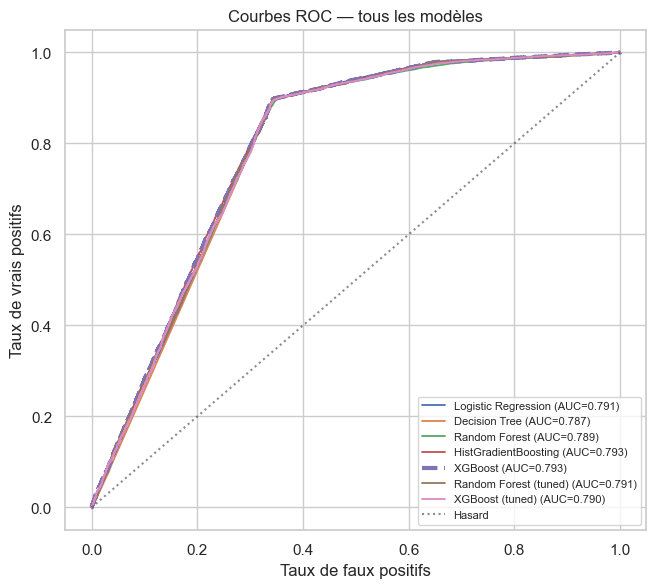

In [14]:
# Courbes ROC de tous les modèles
plt.figure(figsize=(7.5, 6.5))
for name, model in trained.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    style = '--' if name == best_name else '-'
    lw = 3 if name == best_name else 1.3
    plt.plot(fpr, tpr, style, lw=lw, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k:', alpha=.5, label='Hasard')
plt.xlabel('Taux de faux positifs'); plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC — tous les modèles'); plt.legend(loc='lower right', fontsize=8); plt.show()

**Lire une courbe ROC :** plus la courbe se rapproche du coin haut-gauche, mieux c'est. La diagonale
pointillée représente un modèle au hasard. L'**aire sous la courbe (AUC)** résume le tout en un nombre.

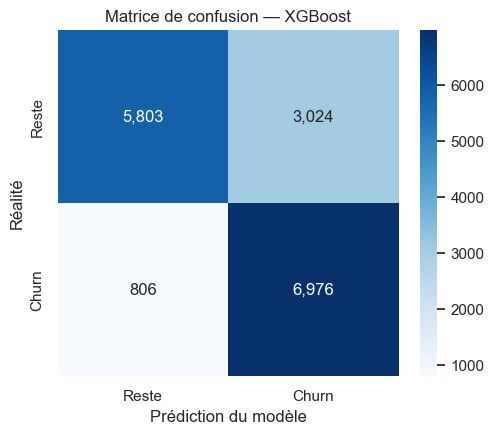

In [15]:
# Matrice de confusion : où le modèle se trompe-t-il ?
cm = confusion_matrix(y_test, final_model.predict(X_test))
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Reste', 'Churn'], yticklabels=['Reste', 'Churn'])
plt.xlabel('Prédiction du modèle'); plt.ylabel('Réalité')
plt.title(f'Matrice de confusion — {best_name}'); plt.show()

**Lire la matrice :** la diagonale = bonnes prédictions. En bas à gauche = churners **manqués**
(faux négatifs, les plus coûteux) ; en haut à droite = fausses alertes (faux positifs).

## 7. Interprétation — qu'est-ce qui pousse les clients à partir ?

Un bon modèle ne sert pas qu'à prédire : il doit aussi **expliquer**. La *feature importance*
indique quelles variables pèsent le plus dans les décisions du modèle.

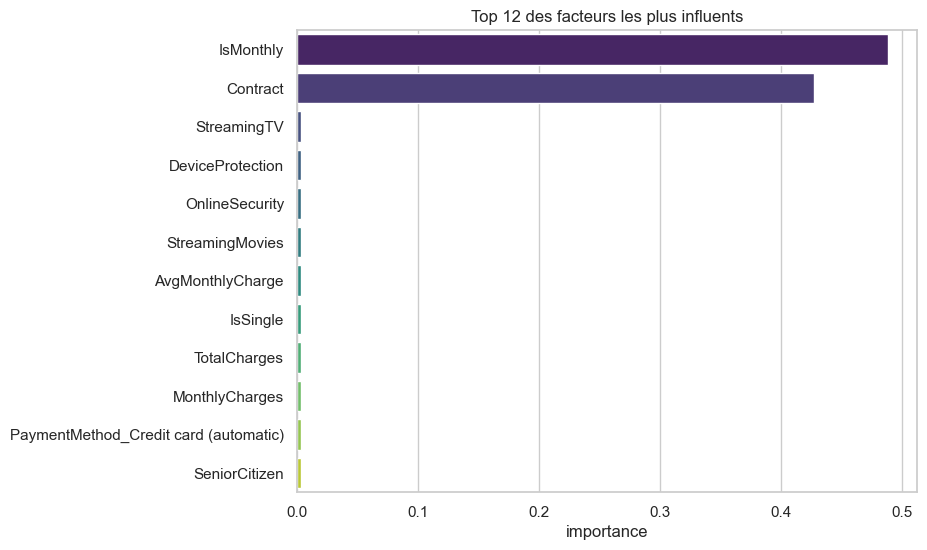

,feature,importance
0,IsMonthly,0.488385
1,Contract,0.427658
2,StreamingTV,0.003515
3,DeviceProtection,0.003483
4,OnlineSecurity,0.003445
5,StreamingMovies,0.003424
6,AvgMonthlyCharge,0.003419
7,IsSingle,0.003413


In [16]:
# Importance : attribut natif si dispo, sinon permutation_importance (universel)
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
elif hasattr(final_model, 'coef_'):
    importances = np.abs(final_model.coef_[0])
else:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(final_model, X_test, y_test, n_repeats=5,
                               scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
    importances = pi.importances_mean
fi = (pd.DataFrame({'feature': X_train.columns, 'importance': importances})
        .sort_values('importance', ascending=False))
plt.figure(figsize=(8, 6))
sns.barplot(data=fi.head(12), y='feature', x='importance', palette='viridis')
plt.title('Top 12 des facteurs les plus influents'); plt.ylabel(''); plt.show()
fi.head(8).reset_index(drop=True)

### 🔑 Le constat majeur

Deux variables dominent très largement : **`IsMonthly`** (contrat au mois) et **`Contract`** (durée
d'engagement). À elles deux, elles concentrent **~92 %** de l'importance ! Autrement dit :

> **Le type de contrat est, de très loin, le premier facteur de churn.**
> Un client au mois part beaucoup ; un client engagé sur 1 ou 2 ans reste.

Cela explique aussi le *plafond* observé : presque toute l'information utile tient dans une seule idée,
donc des modèles plus complexes ne peuvent pas faire beaucoup mieux.

## 8. Régler le seuil de décision selon le besoin métier

Le modèle produit une **probabilité** (ex. 0.67). Pour décider *« on agit ou pas »*, on compare cette
probabilité à un **seuil**. Par défaut il vaut 0.5, mais ce n'est pas une obligation :

- **Seuil bas** (ex. 0.3) → on détecte plus de churners (*Recall* ↑) mais plus de fausses alertes.
- **Seuil haut** (ex. 0.7) → on ne cible que les cas très sûrs (*Precision* ↑) mais on en rate.

Comme un churner manqué coûte cher, on a souvent intérêt à **baisser le seuil**.

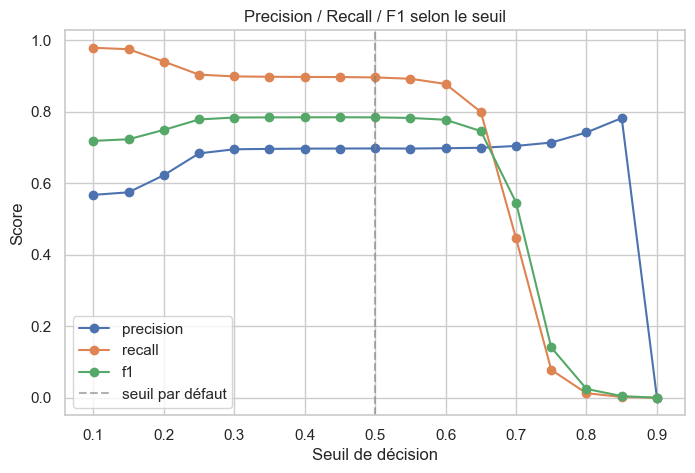

In [17]:
proba = final_model.predict_proba(X_test)[:, 1]
rows = []
for t in np.arange(0.1, 0.91, 0.05):
    pred = (proba >= t).astype(int)
    rows.append({'seuil': round(t, 2),
                 'precision': precision_score(y_test, pred, zero_division=0),
                 'recall': recall_score(y_test, pred),
                 'f1': f1_score(y_test, pred)})
thr = pd.DataFrame(rows)
plt.figure(figsize=(8, 5))
for m, c in [('precision', '#4c72b0'), ('recall', '#dd8452'), ('f1', '#55a868')]:
    plt.plot(thr['seuil'], thr[m], '-o', label=m, color=c)
plt.axvline(0.5, color='gray', ls='--', alpha=.6, label='seuil par défaut')
plt.xlabel('Seuil de décision'); plt.ylabel('Score'); plt.legend()
plt.title('Precision / Recall / F1 selon le seuil'); plt.show()

## 9. Sauvegarde du modèle pour la mise en production

On enregistre le modèle final au format `.pkl`. Il sera rechargé tel quel par l'application Streamlit
(`app/app.py`) pour scorer de nouveaux clients en temps réel.

In [18]:
MODELS.mkdir(exist_ok=True)
joblib.dump(final_model, MODELS / 'best_model.pkl')
joblib.dump({'best_label': best_name}, MODELS / 'best_model_meta.pkl')
print(f'✅ Modèle « {best_name} » sauvegardé dans models/best_model.pkl')

✅ Modèle « XGBoost » sauvegardé dans models/best_model.pkl


## 10. Conclusions

- **5 modèles comparés** rigoureusement (validation croisée) + **optimisation** des deux meilleurs.
- **Modèle retenu : XGBoost** — ROC-AUC ≈ **0.79**, Recall ≈ **0.90** (on détecte 9 churners sur 10).
- Tous les modèles plafonnent ensemble → le signal est **concentré dans le type de contrat**.
- **Driver n°1 du churn : le contrat mensuel.** Les clients engagés sur 1–2 ans partent très peu.
- Le **seuil** peut être abaissé (~0.3–0.4) pour maximiser la détection selon le coût métier.

**Suite du projet :** application de scoring (`app/app.py`) et recommandations
(`reports/business_recommendations.md`).

> ℹ️ Le script `src/train_models.py` reproduit ce pipeline en ligne de commande
> (`python src/train_models.py`) et régénère les figures du dossier `reports/`.